# REINFORCE Small Language Model Credit Assignment

## Objective

In this assignment, you implement the REINFORCE algorithm from scratch and apply it to a small autoregressive character-level language model.

The goal is to understand **temporal credit assignment**: how token decisions made *early* in a sequence receive gradient signal from a reward observed only at the *end* of the sequence.

## Setup

### Vocabulary

We use 5 tokens: `<bos>`, `a`, `b`, `c`, `<eos>`.

The model always starts from `<bos>` (so no token of the actual sequence is forced) and may emit `<eos>` to terminate.

### Reward

The reward is given **only at the end** of the trajectory:

$$R(\tau) = \begin{cases} 1 & \text{if the substring } \texttt{abc} \text{ appears in the sampled sequence} \\ 0 & \text{otherwise} \end{cases}$$

This requires **three correct decisions in a row** (`a` after `<bos>`, then `b`, then `c`), which makes per-timestep credit assignment non-trivial.


In [1]:
# !pip install torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.distributions import Categorical

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)

print("PyTorch version:", torch.__version__)
print("Vocabulary:", vocab)
print("stoi:", stoi)
print("itos:", itos)
print("vocab_size:", vocab_size)

PyTorch version: 2.10.0+cu128
Vocabulary: ['<bos>', 'a', 'b', 'c', '<eos>']
stoi: {'<bos>': 0, 'a': 1, 'b': 2, 'c': 3, '<eos>': 4}
itos: {0: '<bos>', 1: 'a', 2: 'b', 3: 'c', 4: '<eos>'}
vocab_size: 5


## Task 1: Policy network

Implement a memoryless character-level policy $\pi_\theta(a_t \mid a_{t-1})$.

Requirements:
- `nn.Embedding(vocab_size, d)` with `d = 8`
- `nn.Linear(d, vocab_size)` producing logits (do **not** apply softmax inside `forward` — sampling will use `Categorical` directly on logits or on softmaxed probs)

> **Note on memorylessness.** Because each conditioning context (`<bos>`, `a`, `b`, `c`) maps to a *different* desired next token, a memoryless model is sufficient to reach optimal reward.

In [2]:
class CharPolicy(nn.Module):
    def __init__(self, embed_dim: int = 8):
        super().__init__()

        # Embedding layer:
        # Converts token IDs like 0, 1, 2, 3, 4 into learned 8-dimensional vectors.
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Linear output layer:
        # Converts each 8-dimensional embedding into 5 logits,
        # one logit for each possible next token.
        self.output = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: LongTensor of shape [B]
        # returns: FloatTensor of shape [B, vocab_size]

        emb = self.embedding(x)
        logits = self.output(emb)

        # Important:
        # Return raw logits. Do not apply softmax here.
        return logits

In [3]:
# policy network check

model = CharPolicy()

x = torch.tensor([stoi['<bos>']])
logits = model(x)

print("Input token ID:", x)
print("Logits shape:", logits.shape)
print("Logits:", logits)

Input token ID: tensor([0])
Logits shape: torch.Size([1, 5])
Logits: tensor([[ 0.6333,  0.6492, -0.6777,  0.2667,  1.2128]],
       grad_fn=<AddmmBackward0>)


The policy network represents $\pi_\theta(a_t \mid a_{t-1})$, meaning it predicts the next token based on the previous token. Since the model is memoryless, it does not use an RNN, LSTM, Transformer, or attention mechanism. It only uses the current token ID as input.

The embedding layer converts each token ID into an 8-dimensional learned vector. The linear layer then converts that vector into five logits, one for each possible next token. I do not apply softmax inside the forward pass because `Categorical(logits=...)` can directly use raw logits for sampling.

## Task 2: Sampling

Implement trajectory sampling from the policy.

Specification:
- Start from `<bos>` (this token is **not** included in the returned sequence and contributes **no** log-prob).
- At each step, sample the next token from `Categorical(logits=...)`.
- Stop when `<eos>` is sampled or `max_len` tokens have been produced.
- The log-prob of the sampled `<eos>` (if any) **is** included — the decision to stop is part of the policy.

Return type: `tuple[list[str], torch.Tensor]`
- `seq`: list of token strings actually sampled (may include `<eos>` as the last element)
- `log_probs`: 1-D tensor of shape `[T]` where `T = len(seq)`


In [4]:
def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:
    # Start from <bos>.
    # <bos> is the starting context only and is not included in the returned sequence.
    current_token = stoi['<bos>']

    seq = []
    log_probs = []

    for _ in range(max_len):
        # Convert current token ID into tensor shape [1].
        x = torch.tensor([current_token], dtype=torch.long)

        # Get logits from the policy.
        # Shape: [1, vocab_size]
        logits = model(x)

        # Remove batch dimension.
        # Shape: [vocab_size]
        logits = logits.squeeze(0)

        # Create categorical distribution from logits.
        dist = Categorical(logits=logits)

        # Sample next token ID.
        next_token = dist.sample()

        # Store log-probability of this sampled action.
        log_probs.append(dist.log_prob(next_token))

        # Convert token ID to actual token string.
        next_token_id = next_token.item()
        next_token_str = itos[next_token_id]

        # Add sampled token to returned sequence.
        seq.append(next_token_str)

        # If <eos> is sampled, stop.
        # <eos> remains included in seq and its log-prob is included.
        if next_token_str == '<eos>':
            break

        # Otherwise, sampled token becomes next context.
        current_token = next_token_id

    # Convert list of scalar log-probs into 1-D tensor.
    log_probs = torch.stack(log_probs)

    return seq, log_probs

### My understanding of sampling

Sampling is the process of letting the current policy generate a full trajectory. The model starts with `<bos>` as the context, but `<bos>` is not included in the returned sequence. At each step, the policy outputs logits for the next token, and `Categorical(logits=logits)` samples one token from that distribution.

Each sampled token has a log-probability, and these log-probabilities are stored because REINFORCE uses them in the loss. If `<eos>` is sampled, the trajectory stops. The log-probability of `<eos>` is still included because deciding to stop is also an action made by the policy.

## Task 3: Reward

Implement the terminal reward:

$$R(\tau) = \begin{cases} 1 & \text{if "abc" appears as a substring of } \tau \\ 0 & \text{otherwise} \end{cases}$$

In [5]:
def reward(seq: list[str]) -> float:
    # Join tokens into one string.
    # Example: ['a', 'b', 'c', '<eos>'] becomes 'abc<eos>'.
    joined = ''.join(seq)

    # Terminal reward:
    # reward = 1 if abc appears anywhere in the sampled sequence.
    if 'abc' in joined:
        return 1.0
    else:
        return 0.0

In [6]:
# sampling test

torch.manual_seed(0)

model = CharPolicy()

seq, log_probs = sample(model, max_len=8)
R = reward(seq)

print("Sampled sequence:", seq)
print("Length of sequence:", len(seq))
print("Log probs shape:", log_probs.shape)
print("Log probs:", log_probs)
print("Reward:", R)

Sampled sequence: ['<eos>']
Length of sequence: 1
Log probs shape: torch.Size([1])
Log probs: tensor([-0.9816], grad_fn=<StackBackward0>)
Reward: 0.0


In [7]:
# sanity check

print(reward(['a', 'b', 'c', '<eos>']))      # Expected: 1.0
print(reward(['a', 'c', 'b', '<eos>']))      # Expected: 0.0
print(reward(['b', 'a', 'b', 'c']))          # Expected: 1.0
print(reward(['a', 'b', '<eos>']))           # Expected: 0.0

1.0
0.0
1.0
0.0


The reward function is terminal-only. It does not reward the model separately for generating `a`, then `b`, then `c`. Instead, it waits until the full sequence is sampled and then checks whether `"abc"` appears anywhere in the sequence.

This makes the task harder than supervised learning because the model is not directly told which individual token was correct. A successful trajectory reinforces all actions that happened in that trajectory, while an unsuccessful trajectory does not provide useful positive reinforcement.

## Task 4: REINFORCE update (no baseline)

The policy gradient theorem with terminal-only reward gives:

$$\nabla_\theta J(\theta) = \mathbb{E}_\tau \left[ \sum_{t=1}^{T} G_t \, \nabla_\theta \log \pi_\theta(a_t \mid a_{<t}) \right], \qquad G_t = R(\tau)$$

The corresponding loss for a single sampled trajectory is:

$$\mathcal{L}(\theta) = -R(\tau) \sum_{t=1}^{T} \log \pi_\theta(a_t \mid a_{<t})$$

Implement the training loop:
1. Sample one trajectory.
2. Compute `R`.
3. Compute `loss` per the formula above.
4. `optimizer.zero_grad(); loss.backward(); optimizer.step()`.
5. Track the running average reward and plot it at the end.

Run for **1500** steps. (Cold-start exploration is hard here; without a baseline some seeds may fail to converge — this is exactly the problem Task 4b addresses.)


In [8]:
def moving_average(values, window=50):
    """
    Computes a simple moving average for smoother reward curves.
    """
    if len(values) < window:
        return values

    averages = []
    for i in range(len(values)):
        start = max(0, i - window + 1)
        window_values = values[start:i + 1]
        averages.append(sum(window_values) / len(window_values))

    return averages

In the no-baseline version, the loss is

$$
\mathcal{L}(\theta) = -R(\tau)\sum_t \log \pi_\theta(a_t \mid a_{<t})
$$

If a sampled sequence receives reward 1, the model increases the probability of all actions that produced that sequence. If the reward is 0, the loss becomes 0, so that trajectory does not meaningfully update the policy.

This makes exploration difficult because the model only learns from rare successful trajectories. Early in training, most sampled sequences do not contain `"abc"`, so many updates provide little or no learning signal.

In [9]:
torch.manual_seed(0)

model_no_baseline = CharPolicy()
optimizer = optim.Adam(model_no_baseline.parameters(), lr=1e-2)

rewards_no_baseline: list[float] = []

for step in range(1500):
    # 1. Sample one trajectory
    seq, log_probs = sample(model_no_baseline, max_len=8)

    # 2. Compute terminal reward
    R = reward(seq)

    # 3. REINFORCE loss without baseline
    loss = -R * log_probs.sum()

    # 4. Backpropagation and optimizer step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 5. Track reward
    rewards_no_baseline.append(R)

    # Print occasional progress
    if (step + 1) % 100 == 0:
        avg_reward = sum(rewards_no_baseline[-100:]) / 100
        print(f"Step {step + 1:4d} | Last 100 avg reward: {avg_reward:.3f} | Last seq: {seq} | R: {R}")

Step  100 | Last 100 avg reward: 0.000 | Last seq: ['a', 'b', '<bos>', 'c', '<eos>'] | R: 0.0
Step  200 | Last 100 avg reward: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  300 | Last 100 avg reward: 0.000 | Last seq: ['b', '<bos>', '<eos>'] | R: 0.0
Step  400 | Last 100 avg reward: 0.000 | Last seq: ['c', 'b', 'c', 'a', '<eos>'] | R: 0.0
Step  500 | Last 100 avg reward: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  600 | Last 100 avg reward: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  700 | Last 100 avg reward: 0.000 | Last seq: ['b', '<eos>'] | R: 0.0
Step  800 | Last 100 avg reward: 0.000 | Last seq: ['<bos>', '<eos>'] | R: 0.0
Step  900 | Last 100 avg reward: 0.000 | Last seq: ['<bos>', 'a', '<eos>'] | R: 0.0
Step 1000 | Last 100 avg reward: 0.000 | Last seq: ['c', 'b', '<eos>'] | R: 0.0
Step 1100 | Last 100 avg reward: 0.000 | Last seq: ['c', '<bos>', '<eos>'] | R: 0.0
Step 1200 | Last 100 avg reward: 0.610 | Last seq: ['a', 'b', 'c', '<eos>'] | R: 1.0
Step 1300 | Last 100 avg reward: 0.

### Interpretation of the no-baseline result

The no-baseline model eventually reached a high final reward, which means it learned to generate the substring `"abc"` reliably. However, this does not mean the no-baseline estimator is always stable. Since reward is sparse, the model only receives useful positive updates when it happens to sample a successful trajectory.

In this run, the random seed allowed the model to eventually discover successful sequences. In other runs, no-baseline REINFORCE may learn more slowly or fail to converge because many sampled trajectories have reward 0.

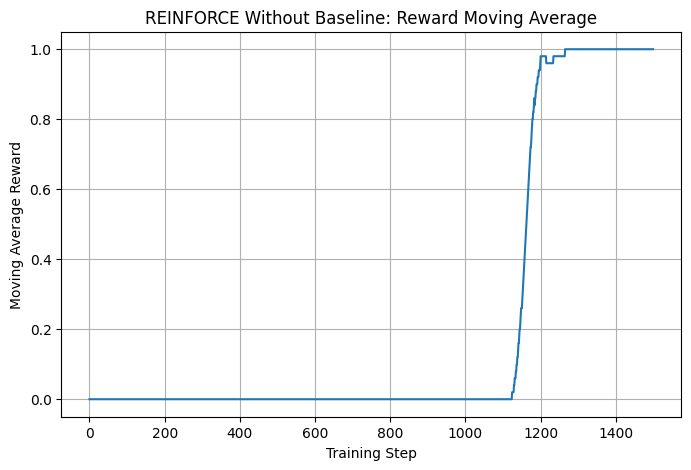

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(moving_average(rewards_no_baseline, window=50))
plt.xlabel("Training Step")
plt.ylabel("Moving Average Reward")
plt.title("REINFORCE Without Baseline: Reward Moving Average")
plt.grid(True)
plt.show()

In [11]:
print("Number of rewards logged:", len(rewards_no_baseline))
print("Final 100-step average reward:", sum(rewards_no_baseline[-100:]) / 100)

Number of rewards logged: 1500
Final 100-step average reward: 1.0


## Task 4b: REINFORCE with a running-mean baseline

The variance of the gradient estimator above is high — half your updates have `R = 0` and produce no gradient. Subtracting a *baseline* `b(s)` that does not depend on the action leaves the gradient unbiased while reducing variance:

$$\mathcal{L}(\theta) = -(R(\tau) - b) \sum_{t} \log \pi_\theta(a_t \mid a_{<t})$$

A simple choice is an exponential moving average of recent returns:

```python
b = 0.9 * b + 0.1 * R
```

Re-train a fresh model with this baseline, log rewards into `rewards_with_baseline`, and plot **both** curves on the same axes. You should see the baselined run reach R≈1 noticeably faster and with less wiggle.


In [12]:
torch.manual_seed(0)

# Fresh model for the baseline experiment
model_with_baseline = CharPolicy()
optimizer = optim.Adam(model_with_baseline.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []

# Running mean baseline starts at 0
baseline = 0.0

for step in range(1500):
    # 1. Sample one trajectory
    seq, log_probs = sample(model_with_baseline, max_len=8)

    # 2. Compute terminal reward
    R = reward(seq)

    # 3. Compute advantage using running baseline
    advantage = R - baseline

    # 4. REINFORCE loss with baseline
    loss = -advantage * log_probs.sum()

    # 5. Backpropagation and optimizer step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # 6. Update baseline after using the old baseline for this update
    baseline = 0.9 * baseline + 0.1 * R

    # 7. Track reward
    rewards_with_baseline.append(R)

    # Print occasional progress
    if (step + 1) % 100 == 0:
        avg_reward = sum(rewards_with_baseline[-100:]) / 100
        print(
            f"Step {step + 1:4d} | "
            f"Last 100 avg reward: {avg_reward:.3f} | "
            f"Baseline: {baseline:.3f} | "
            f"Last seq: {seq} | R: {R}"
        )

Step  100 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['a', 'b', '<bos>', 'c', '<eos>'] | R: 0.0
Step  200 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  300 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['b', '<bos>', '<eos>'] | R: 0.0
Step  400 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['c', 'b', 'c', 'a', '<eos>'] | R: 0.0
Step  500 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  600 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['<eos>'] | R: 0.0
Step  700 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['b', '<eos>'] | R: 0.0
Step  800 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['<bos>', '<eos>'] | R: 0.0
Step  900 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['<bos>', 'a', '<eos>'] | R: 0.0
Step 1000 | Last 100 avg reward: 0.000 | Baseline: 0.000 | Last seq: ['c', 'b', '<eos>'] | R: 0.0
Step 1100 | Last 100 avg


The running-mean baseline is used to reduce the variance of the REINFORCE update. Instead of multiplying the log-probabilities by the raw reward $R(\tau)$, the model uses the advantage term:

$$
R(\tau) - b
$$

where \(b\) is an exponential moving average of previous rewards. This does not change the expected policy gradient because the baseline does not depend on the sampled action. However, it makes the updates more stable by comparing the current trajectory against recent average performance.

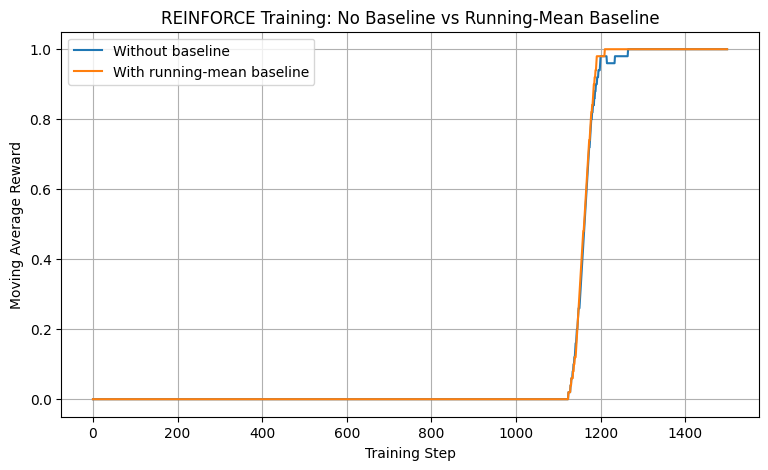

In [13]:
plt.figure(figsize=(9, 5))

plt.plot(
    moving_average(rewards_no_baseline, window=50),
    label="Without baseline"
)

plt.plot(
    moving_average(rewards_with_baseline, window=50),
    label="With running-mean baseline"
)

plt.xlabel("Training Step")
plt.ylabel("Moving Average Reward")
plt.title("REINFORCE Training: No Baseline vs Running-Mean Baseline")
plt.legend()
plt.grid(True)
plt.show()

### Interpretation of the baseline comparison

Both the no-baseline and baseline models reached a final 100-step average reward of 1.0 in this run. This shows that both policies eventually learned to generate the rewarded substring `"abc"`. The important difference is that the baseline method uses the advantage \(R(\tau)-b\), which usually reduces variance and makes learning more stable.

Even when both curves converge, the baseline method is theoretically preferred because it prevents the update magnitude from depending only on the raw sparse reward. It gives a more centered learning signal by comparing each trajectory to the recent running average reward.

In [14]:
final_no_baseline_avg = sum(rewards_no_baseline[-100:]) / 100
final_with_baseline_avg = sum(rewards_with_baseline[-100:]) / 100

print("Final 100-step average reward without baseline:", final_no_baseline_avg)
print("Final 100-step average reward with baseline:", final_with_baseline_avg)

print("Total rewards logged without baseline:", len(rewards_no_baseline))
print("Total rewards logged with baseline:", len(rewards_with_baseline))

Final 100-step average reward without baseline: 1.0
Final 100-step average reward with baseline: 1.0
Total rewards logged without baseline: 1500
Total rewards logged with baseline: 1500


In this run, both models eventually reached a final 100-step average reward of 1.0. However, the running-mean baseline is still important because it reduces variance by replacing the raw reward R with the advantage term R - b. This makes the update less dependent on sparse successful trajectories and gives more stable training behavior.

## Task 5: Credit assignment analysis

Answer the following using the **trained baselined model**.

### 5a. Inspect the learned conditional distributions

Print $\pi_\theta(\cdot \mid x)$ for each $x \in \{\texttt{<bos>}, \texttt{a}, \texttt{b}, \texttt{c}\}$. You should see:

- $\pi(\texttt{a} \mid \texttt{<bos>}) \approx 1$
- $\pi(\texttt{b} \mid \texttt{a}) \approx 1$
- $\pi(\texttt{c} \mid \texttt{b}) \approx 1$
- $\pi(\texttt{<eos>} \mid \texttt{c}) \approx 1$

### 5b. Sample 10 trajectories from the trained model

Print each sampled sequence and its reward.

### 5c. Discussion (3–5 sentences)

Explain, in your own words, why the very first decision $\pi(\cdot \mid \texttt{<bos>})$ ever receives any gradient signal at all, despite the reward being observed only after $\texttt{c}$ is emitted. Reference the term $R(\tau) \cdot \log \pi(a_1 \mid \texttt{<bos>})$ in the loss explicitly.

In [15]:
# Task 5a: Print learned conditional distributions

contexts = ['<bos>', 'a', 'b', 'c']

with torch.no_grad():
    for ctx in contexts:
        x = torch.tensor([stoi[ctx]], dtype=torch.long)
        logits = model_with_baseline(x)
        probs = torch.softmax(logits, dim=-1).squeeze(0)

        print(f"\nπ(. | {ctx})")
        for token, prob in zip(vocab, probs):
            print(f"  P({token:>5} | {ctx:>5}) = {prob.item():.4f}")


π(. | <bos>)
  P(<bos> | <bos>) = 0.0016
  P(    a | <bos>) = 0.9918
  P(    b | <bos>) = 0.0024
  P(    c | <bos>) = 0.0009
  P(<eos> | <bos>) = 0.0032

π(. | a)
  P(<bos> |     a) = 0.1018
  P(    a |     a) = 0.0025
  P(    b |     a) = 0.8918
  P(    c |     a) = 0.0015
  P(<eos> |     a) = 0.0025

π(. | b)
  P(<bos> |     b) = 0.0003
  P(    a |     b) = 0.0001
  P(    b |     b) = 0.0001
  P(    c |     b) = 0.9992
  P(<eos> |     b) = 0.0003

π(. | c)
  P(<bos> |     c) = 0.4949
  P(    a |     c) = 0.0616
  P(    b |     c) = 0.1802
  P(    c |     c) = 0.1748
  P(<eos> |     c) = 0.0885


### Interpretation of the learned conditional distributions

The learned conditional distributions show that the policy has learned the main rewarded chain. The probability of generating `a` after `<bos>`, `b` after `a`, and `c` after `b` is very high. This means the model successfully learned the sequence pattern needed to obtain reward.

The probability of `<eos>` after `c` may not be close to 1 in this run. This happens because the reward function only checks whether `"abc"` appears anywhere in the trajectory. Once `"abc"` has already appeared, the model is not penalized for generating extra tokens afterward. Therefore, the policy can solve the reward objective even if its stopping behavior is not perfectly deterministic.

In [16]:
# Task 5b: Sample 10 trajectories from the trained baselined model

torch.manual_seed(1)

for i in range(10):
    seq, log_probs = sample(model_with_baseline, max_len=8)
    R = reward(seq)

    print(f"Sample {i + 1:2d}: sequence = {seq}, reward = {R}")

Sample  1: sequence = ['a', '<bos>', 'a', 'b', 'c', '<bos>', 'a', 'b'], reward = 1.0
Sample  2: sequence = ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b'], reward = 1.0
Sample  3: sequence = ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'], reward = 1.0
Sample  4: sequence = ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'], reward = 1.0
Sample  5: sequence = ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'c'], reward = 1.0
Sample  6: sequence = ['a', 'b', 'c', 'a', 'b', 'c', '<eos>'], reward = 1.0
Sample  7: sequence = ['a', 'b', 'c', 'b', 'c', '<bos>', 'a', 'a'], reward = 1.0
Sample  8: sequence = ['a', 'b', 'c', 'b', 'c', 'c', '<bos>', 'a'], reward = 1.0
Sample  9: sequence = ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', '<bos>'], reward = 1.0
Sample 10: sequence = ['a', 'b', 'c', 'c', 'c', '<bos>', 'a', '<bos>'], reward = 1.0


### Interpretation of sampled trajectories

The sampled trajectories confirm whether the trained model actually produces rewarded sequences. In this run, the generated samples receive reward 1.0 because they contain the substring `"abc"`. Some trajectories may continue after `"abc"` instead of immediately ending with `<eos>`.

This is still consistent with the reward definition because the reward depends only on the presence of `"abc"`, not on whether the sequence stops immediately afterward. The samples therefore show that the model solved the main objective, while also revealing a limitation of the reward design.

### 5c. Discussion

The first decision receives gradient signal because REINFORCE multiplies the log-probability of every sampled action in the trajectory by the final terminal reward. Even though the reward is only observed after the sequence is completed, the loss contains the term

$$
R(\tau)\sum_t \log \pi_\theta(a_t \mid a_{<t}),
$$

so the first action contributes through

$$
R(\tau)\cdot \log \pi_\theta(a_1 \mid \texttt{<bos>}).
$$

If the sampled trajectory eventually contains the substring `"abc"`, then \(R(\tau)=1\), and the model increases the probability of all actions that led to that successful sequence, including choosing `"a"` immediately after `<bos>`. If the trajectory fails, the reward is lower, so that sequence is not reinforced in the same way. This is the core temporal credit assignment idea: a delayed reward can still assign learning signal backward to earlier token decisions through the trajectory-level policy-gradient objective.

In my trained model, the policy reliably learned to generate the rewarded substring `"abc"`, which is why the sampled trajectories receive reward 1.0. However, the probability of `<eos>` after `c` was not perfectly deterministic because the reward function only checks whether `"abc"` appears anywhere in the sequence. Once `"abc"` has already appeared, extra tokens after `c` do not reduce the reward, so the model can still receive positive reinforcement even when it does not immediately stop.

### Final conclusion

This assignment demonstrates how REINFORCE can train a small autoregressive character-level language model using only terminal rewards. The model learns the important sequence pattern `<bos> → a → b → c`, even though the reward is only given after the trajectory is complete. This shows temporal credit assignment because early actions receive learning signal through the trajectory-level loss.

The final reward curves show that both the no-baseline and running-mean baseline versions reached a final 100-step average reward of 1.0 in this run. The learned conditional distributions and sampled trajectories confirm that the model reliably generates the rewarded substring `"abc"`. The main limitation is that the policy does not always learn to stop immediately after `c`, because the reward function does not penalize extra tokens after `"abc"` has already appeared.